# Collated Models Notebook
This notebook serves to collect all the different models used in the senior design project — and compare them. Primarily this was made to generate the necessary figures (overlaid ROC curves).

## Imports

In [1]:
# Import basic modules
import flowkit as fk
import pandas as pd
import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# Import classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import classification_report

## Data Loading
CLL_102 (n=102) as the training dataset,
CLL_162 (n=81) as the validation dataset.
See https://github.com/erobl/csnn for the CLL_train.csv and CLL_val.csv files.

In [3]:
# Load the CLL_102 labels dataset from erobl/csnn (training dataset, n=102)
data_dir = "../datasets/CLL_288/CLL_102/"
CLL_102 = pd.read_csv(os.path.join(data_dir, "CLL_train.csv"))

# Load the relevant files into dataframes, store in a list
files = []
for file in CLL_102['File'].to_numpy():
    file_asdf = pd.read_csv(os.path.join(data_dir, f'{file.split('/')[1]}' + '.fcs.txt'), sep='\t')
    files.append(file_asdf)
CLL_102['raw'] = files
del files

# Remove any irrelevant columns (e.g. Time, Batch)
dataonly = []
for dataset in CLL_102['raw'].to_numpy():
    dropped = dataset.drop(columns=['Time'])
    # dropped = dropped.drop(columns=['FSC.A', 'FSC.H', 'FSC.W', 'SSC.A', 'SSC.H', 'SSC.W', 'CD19', 'CD79b', 'CD3', 'CD81', 'CD10', 'CD43', 'CD38'])
    dataonly.append(dropped)
CLL_102['raw'] = dataonly
del dataonly

# Turn data into its set of features
features_list = []
for index, row in CLL_102.iterrows():
    cell_data = row['raw']
    sample_id = row['File']
    label = row['Label']
    
    patient_features = {'File': sample_id, 'Label': label}
    
    for channel in cell_data.columns:
        # FEATURES:
        patient_features[f'{channel}_median'] = cell_data[channel].median()
        patient_features[f'{channel}_stdev']    = cell_data[channel].std()
        patient_features[f'{channel}_iqr']    = cell_data[channel].quantile(0.75) - cell_data[channel].quantile(0.25)
        patient_features[f'{channel}_p90']    = cell_data[channel].quantile(0.90)
        patient_features[f'{channel}_p10']    = cell_data[channel].quantile(0.10)
    features_list.append(patient_features)

# Collect final dataset
CLL_102 = pd.DataFrame(features_list).set_index('File')
del features_list

# Check correctness with visualization
CLL_102

,Label,FSC-A_median,FSC-A_stdev,FSC-A_iqr,FSC-A_p90,FSC-A_p10,FSC-H_median,FSC-H_stdev,FSC-H_iqr,FSC-H_p90,...,CD43_median,CD43_stdev,CD43_iqr,CD43_p90,CD43_p10,CD38_median,CD38_stdev,CD38_iqr,CD38_p90,CD38_p10
File,,,,,,,,,,,,,,,,,,,,,
CLL_102/13045.txt,0.0,2591.841437,1286.173850,1744.129869,4094.984379,174.811803,1957.342329,843.654428,1127.330174,2426.801125,...,2393.075974,652.419714,468.325836,2732.704194,957.162506,1249.423573,577.551048,716.174692,2080.040015,510.540357
CLL_102/15030.txt,0.0,2570.962258,1333.071856,1853.764229,4094.984379,168.938741,1904.409943,834.754747,941.348248,2490.721453,...,2329.210373,719.316781,500.813753,2756.004949,710.102150,1463.498526,585.514504,763.518622,2212.611436,587.054485
CLL_102/15032.txt,0.0,2304.388562,1301.121588,1768.030710,4094.984379,154.415543,1766.357718,835.743953,1136.870813,2430.047207,...,2330.091551,695.186238,469.699601,2731.286341,700.023199,1430.366232,607.970201,849.314903,2249.500233,560.627492
CLL_102/16329.txt,0.0,2374.794830,1342.902788,2479.320712,4094.984379,166.862013,1790.515881,856.506081,1631.535172,2384.575499,...,2388.612965,782.954962,957.082697,2749.709162,632.645682,1435.854573,634.466234,903.763527,2273.491400,530.232892
CLL_102/16331.txt,0.0,2697.507650,1253.570793,1613.930127,4094.984379,232.313639,1986.561756,783.077412,763.911109,2497.360456,...,2375.327954,655.219575,404.232511,2846.950092,960.584725,1494.743843,598.090544,759.878067,2284.932039,620.919430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CLL_102/8535.txt,1.0,1745.714443,834.239423,719.007463,3490.079118,1464.459883,1527.556658,479.848272,466.081495,2380.217188,...,2220.588756,408.456201,542.233901,2781.144923,1825.579176,630.817069,462.669616,727.798113,1237.257895,0.000000
CLL_102/9343.txt,1.0,1802.810181,1028.003737,1559.751860,3266.532073,537.799883,1465.993567,626.283442,1069.395103,2198.011683,...,2278.651874,686.421321,562.973118,2705.501210,832.270187,1371.489750,673.403356,960.422197,2315.960550,502.600858
CLL_102/9422.txt,1.0,2288.644604,832.248039,1217.529217,3485.038113,1481.297080,1795.584955,487.744011,709.393172,2397.903494,...,2503.793201,359.509997,344.861200,2828.822267,2065.319619,1331.199724,729.259329,1123.321220,2109.269152,15.712302


In [4]:
# Load the CLL_162 labels dataset from erobl/csnn (validation dataset, n=81)
data_dir = "../datasets/CLL_288/CLL_162/"
CLL_162 = pd.read_csv(os.path.join(data_dir, "CLL_val.csv"))

files = []
for file in CLL_162['File'].to_numpy():
    file_asdf = pd.read_csv(os.path.join(data_dir, f'{file.split('/')[1]}'), sep='\t')
    files.append(file_asdf)
CLL_162['raw'] = files
del files

# Turn data into its set of features
features_list = []
for index, row in CLL_162.iterrows():
    cell_data = row['raw']
    sample_id = row['File']
    label = row['Label']
    
    patient_features = {'File': sample_id, 'Label': label}
    
    for channel in cell_data.columns:
        patient_features[f'{channel}_median'] = cell_data[channel].median()
        patient_features[f'{channel}_stdev']    = cell_data[channel].std()
        patient_features[f'{channel}_iqr']    = cell_data[channel].quantile(0.75) - cell_data[channel].quantile(0.25)
        patient_features[f'{channel}_p90']    = cell_data[channel].quantile(0.90)
        patient_features[f'{channel}_p10']    = cell_data[channel].quantile(0.10)
    features_list.append(patient_features)

# Collect final dataset
CLL_162 = pd.DataFrame(features_list).set_index('File')
del features_list

# Check correctness with visualization
CLL_162

,Label,FSC-A_median,FSC-A_stdev,FSC-A_iqr,FSC-A_p90,FSC-A_p10,FSC-H_median,FSC-H_stdev,FSC-H_iqr,FSC-H_p90,...,CD43_median,CD43_stdev,CD43_iqr,CD43_p90,CD43_p10,CD38_median,CD38_stdev,CD38_iqr,CD38_p90,CD38_p10
File,,,,,,,,,,,,,,,,,,,,,
CLL_162/223.fcs.txt,0,2021.403834,1215.371116,2091.456841,3583.821436,138.618646,1687.119255,860.740361,1556.182480,2430.439299,...,2103.139398,735.913946,1128.807406,2519.365729,566.882080,1570.087233,731.798961,1127.999977,2531.235619,539.053817
CLL_162/233.fcs.txt,0,1916.035827,1391.476024,2516.056156,4094.984379,117.588785,1509.529810,932.613659,1750.021863,2468.339418,...,2055.679646,894.475617,1746.697884,2815.406286,526.861136,1443.178851,769.681833,1209.128797,2564.476690,497.193345
CLL_162/243.fcs.txt,0,1548.525231,940.070724,940.636446,2842.671883,246.805889,1280.835657,532.608781,564.518394,1845.975775,...,2220.577150,587.603108,457.995766,2556.236440,935.538696,1679.321346,605.770222,838.625848,2447.808299,759.509880
CLL_162/245.fcs.txt,0,1733.420448,1083.361859,1942.105991,2812.107619,125.593552,1361.042633,694.708505,1391.211047,1914.643381,...,2110.618319,694.607209,1112.731233,2551.799556,696.305752,1298.925354,619.381829,854.329990,2160.360664,479.427087
CLL_162/269.fcs.txt,0,1899.502389,1084.031623,1034.526787,3359.818252,171.174700,1406.476851,599.938722,631.115413,1820.289860,...,2202.585477,638.762006,393.281784,2522.490329,733.201131,1264.132160,532.771232,664.905736,1864.105783,511.350751
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CLL_162/193.fcs.txt,1,260.651345,718.921453,502.844689,1528.531761,98.588428,242.581387,481.718031,456.454940,1241.057871,...,561.484440,635.231542,239.996418,2036.962732,437.710865,725.250188,460.703666,387.693552,1439.968344,445.402619
CLL_162/195.fcs.txt,1,2441.554407,1362.518872,2527.056095,4094.984379,157.418228,1825.616684,889.688558,1668.225431,2499.041296,...,2196.329636,742.198167,966.253128,2593.453963,594.900211,1589.656513,693.788367,1076.375058,2436.487582,539.714740
CLL_162/199.fcs.txt,1,1926.874427,1188.516796,2124.598093,3282.336685,152.055367,1591.064587,806.284054,1586.315746,2215.101259,...,2026.077332,858.572701,1747.390662,2674.802664,496.738488,1576.951878,714.587442,1181.641755,2357.225841,501.799005


## Function Definition

In [5]:
# Define logistic regression function (so we can run it several times!)
def log_reg(X, y, X_val, y_val, C=1, max_iter=100):
    # set up model
    lr_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(penalty='elasticnet', l1_ratio=1, solver='saga', C=C, random_state=1, max_iter=max_iter))
    ])

    # use cross-validation
    loo = LeaveOneOut()
    y_pred = cross_val_predict(lr_pipeline, X, y, cv=loo)

    # fit pipeline, L1 regularization for feature set
    lr_pipeline.fit(X, y)
    model_coeffs = lr_pipeline.named_steps['model'].coef_[0]
    coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model_coeffs})
    significant_features = coef_df[coef_df['Coefficient'] != 0].sort_values(by='Coefficient')

    # test model on validation dataset
    y_validation_pred = lr_pipeline.predict(X_val)

    # get ROC for AUROC
    y_probas = cross_val_predict(lr_pipeline, X_val, y_val, cv=loo, method='predict_proba')
    y_scores = y_probas[:, 1] 
    
    fpr, tpr, thresholds = roc_curve(y_val, y_scores)
    roc_auc = auc(fpr, tpr)

    return {
        'class_report': classification_report(y, y_pred, target_names=["Healthy", "Cancer"]),
        'significant_features': significant_features,
        'validation_report': classification_report(y_val, y_validation_pred, target_names=["Healthy", "Cancer"]),
        'roc_auc': (fpr, tpr, roc_auc)
           }

In [6]:
# Define very similar random forest function
def random_forest(X, y, X_val, y_val, n_estimators = 100, max_depth = 5):
    # set up model
    rf_pipeline = Pipeline([
        ('model', RandomForestClassifier(
            n_estimators=n_estimators, 
            max_depth=max_depth,
            random_state=1,
            class_weight='balanced'
        ))
    ])

    # use cross-validation
    loo = LeaveOneOut()
    y_pred = cross_val_predict(rf_pipeline, X, y, cv=loo)

    # fit to data
    rf_pipeline.fit(X, y)

    # collect "important features"
    importances = rf_pipeline.named_steps['model'].feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    # test model on validation dataset
    y_validation_pred = rf_pipeline.predict(X_val)

    # get ROC for AUROC
    y_probas = cross_val_predict(rf_pipeline, X_val, y_val, cv=loo, method='predict_proba')
    y_scores = y_probas[:, 1] 
    
    fpr, tpr, thresholds = roc_curve(y_val, y_scores)
    roc_auc = auc(fpr, tpr)

    return {
        'class_report': classification_report(y, y_pred, target_names=["Healthy", "Cancer"]),
        'significant_features': feature_importance_df,
        'validation_report': classification_report(y_val, y_validation_pred, target_names=["Healthy", "Cancer"]),
        'roc_auc': (fpr, tpr, roc_auc)
    }

## Raw Dataset Testing LR + RF

In [7]:
# test functions (and plot AUROC to verify working):
models = {}
models['lr_raw'] = log_reg(CLL_102.drop(columns=['Label']),
                           CLL_102['Label'],
                           CLL_162.drop(columns=['Label']),
                           CLL_162['Label'],
                           C=1,
                           max_iter=10000)

models['rf_raw'] = random_forest(CLL_102.drop(columns=['Label']),
                                 CLL_102['Label'],
                                 CLL_162.drop(columns=['Label']),
                                 CLL_162['Label'],
                                 n_estimators=100,
                                 max_depth=5)


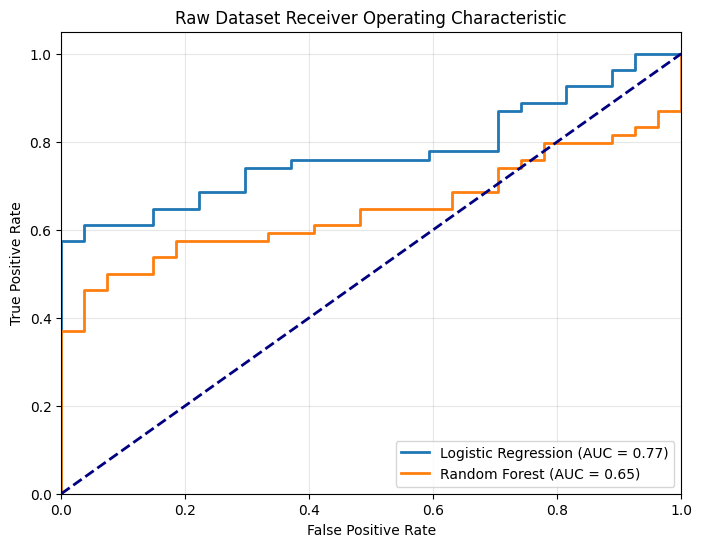

In [8]:
plt.figure(figsize=(8, 6))

lw = 2
fpr, tpr, roc_auc = models['lr_raw']['roc_auc']
plt.plot(
    fpr, 
    tpr, 
    color=sns.color_palette("tab10")[0],
    lw=lw, 
    label=f"Logistic Regression (AUC = {roc_auc:.2f})"
)

fpr, tpr, roc_auc = models['rf_raw']['roc_auc']
plt.plot(
    fpr, 
    tpr, 
    color=sns.color_palette("tab10")[1],
    lw=lw, 
    label=f"Random Forest (AUC = {roc_auc:.2f})"
)

plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Raw Dataset Receiver Operating Characteristic")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## CD19± Dataset Testing LR + RF

In [9]:
# Unfortunately we have to reload the entirety of the CLL_102 and CLL_162 datasets to perform this work.
# For the sake of memory, delete the previous datasets for now
del CLL_102, CLL_162

In [10]:
data_dir = "../datasets/CLL_288/CLL_102/"
CLL_102 = pd.read_csv(os.path.join(data_dir, "CLL_train.csv"))

# Load the relevant files into dataframes, store in a list
files = []
for file in CLL_102['File'].to_numpy():
    file_asdf = pd.read_csv(os.path.join(data_dir, f'{file.split('/')[1]}' + '.fcs.txt'), sep='\t')
    files.append(file_asdf)
CLL_102['raw'] = files
del files

# Remove any irrelevant columns (e.g. Time, Batch)
dataonly = []
for dataset in CLL_102['raw'].to_numpy():
    dropped = dataset.drop(columns=['Time'])
    # dropped = dropped.drop(columns=['FSC.A', 'FSC.H', 'FSC.W', 'SSC.A', 'SSC.H', 'SSC.W', 'CD19', 'CD79b', 'CD3', 'CD81', 'CD10', 'CD43', 'CD38'])
    dataonly.append(dropped)
CLL_102['raw'] = dataonly
del dataonly

# Process by CD19 threshold (±)
CD19_THRESHOLD = 2000
features_list = []
for index, row in CLL_102.iterrows():
    
    cell_data = row['raw']
    sample_id = row['File']
    label = row['Label']
    
    patient_features = {'File': sample_id, 'Label': label}
    
    # split populations
    cd19_pos = cell_data[cell_data["CD19"] >= CD19_THRESHOLD]
    cd19_neg = cell_data[cell_data["CD19"] < CD19_THRESHOLD]

    for channel in cell_data.columns:
        
        # CD19+ statistics
        if len(cd19_pos) > 0:
            patient_features[f'CD19pos_{channel}_median'] = cd19_pos[channel].median()
            patient_features[f'CD19pos_{channel}_stdev']  = cd19_pos[channel].std()
            patient_features[f'CD19pos_{channel}_iqr']    = cd19_pos[channel].quantile(0.75) - cd19_pos[channel].quantile(0.25)
            patient_features[f'CD19pos_{channel}_p90']    = cd19_pos[channel].quantile(0.90)
            patient_features[f'CD19pos_{channel}_p10']    = cd19_pos[channel].quantile(0.10)
        else:
            patient_features[f'CD19pos_{channel}_median'] = np.nan
            patient_features[f'CD19pos_{channel}_stdev']  = np.nan
            patient_features[f'CD19pos_{channel}_iqr']    = np.nan
            patient_features[f'CD19pos_{channel}_p90']    = np.nan
            patient_features[f'CD19pos_{channel}_p10']    = np.nan

        # CD19- statistics
        if len(cd19_neg) > 0:
            patient_features[f'CD19neg_{channel}_median'] = cd19_neg[channel].median()
            patient_features[f'CD19neg_{channel}_stdev']  = cd19_neg[channel].std()
            patient_features[f'CD19neg_{channel}_iqr']    = cd19_neg[channel].quantile(0.75) - cd19_neg[channel].quantile(0.25)
            patient_features[f'CD19neg_{channel}_p90']    = cd19_neg[channel].quantile(0.90)
            patient_features[f'CD19neg_{channel}_p10']    = cd19_neg[channel].quantile(0.10)
        else:
            patient_features[f'CD19neg_{channel}_median'] = np.nan
            patient_features[f'CD19neg_{channel}_stdev']  = np.nan
            patient_features[f'CD19neg_{channel}_iqr']    = np.nan
            patient_features[f'CD19neg_{channel}_p90']    = np.nan
            patient_features[f'CD19neg_{channel}_p10']    = np.nan

    features_list.append(patient_features)

# Collect final dataset
CLL_102 = pd.DataFrame(features_list).set_index('File')
del features_list

# Check correctness with visualization
CLL_102

,Label,CD19pos_FSC-A_median,CD19pos_FSC-A_stdev,CD19pos_FSC-A_iqr,CD19pos_FSC-A_p90,CD19pos_FSC-A_p10,CD19neg_FSC-A_median,CD19neg_FSC-A_stdev,CD19neg_FSC-A_iqr,CD19neg_FSC-A_p90,...,CD19pos_CD38_median,CD19pos_CD38_stdev,CD19pos_CD38_iqr,CD19pos_CD38_p90,CD19pos_CD38_p10,CD19neg_CD38_median,CD19neg_CD38_stdev,CD19neg_CD38_iqr,CD19neg_CD38_p90,CD19neg_CD38_p10
File,,,,,,,,,,,,,,,,,,,,,
CLL_102/13045.txt,0.0,4094.984379,1158.087380,1784.259779,4094.984379,1539.799249,2587.853397,1284.211388,1747.853539,4094.984379,...,2407.389659,867.611744,853.471295,3099.372982,756.115604,1246.697570,570.622974,713.497766,2057.028794,510.246809
CLL_102/15030.txt,0.0,1639.594606,1185.810415,2622.386468,4094.984379,1365.576560,2583.296649,1336.459983,1826.011546,4094.984379,...,2172.688410,568.926582,597.070948,2812.033628,1548.109366,1452.691336,574.711378,753.010099,2186.651142,582.642224
CLL_102/15032.txt,0.0,4094.984379,1146.895182,1645.433756,4094.984379,1655.907639,2295.282021,1299.201069,1767.820739,4094.984379,...,2162.381830,709.475221,819.949804,3022.924192,1249.529036,1427.560989,604.587783,846.115918,2243.322300,559.630899
CLL_102/16329.txt,0.0,2231.611046,1117.267918,2324.265422,4094.984379,1508.891270,2376.604203,1343.618243,2491.959578,4094.984379,...,1574.425359,1135.587661,2075.749705,3014.627586,0.000000,1435.640785,629.695043,899.907056,2266.341351,533.439634
CLL_102/16331.txt,0.0,4094.984379,1046.288754,0.000000,4094.984379,1709.851594,2696.227811,1253.007256,1610.033343,4094.984379,...,2415.695930,707.778044,689.318910,3130.132094,1382.946612,1493.777412,596.620396,757.518132,2283.010781,620.498101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CLL_102/8535.txt,1.0,1673.928751,593.421594,281.355609,2530.962724,1467.080020,2683.170209,1026.295232,1591.961645,4094.984379,...,704.665715,418.091867,605.667803,1225.261983,107.426119,356.568649,523.189320,867.707551,1272.053143,0.000000
CLL_102/9343.txt,1.0,1579.672105,601.245650,160.138384,2049.400659,1424.204357,2094.243712,1100.732102,1968.447192,3391.078880,...,834.051147,651.769824,1033.673637,1788.197788,3.206050,1472.727922,632.981395,915.936370,2366.969534,635.571596
CLL_102/9422.txt,1.0,1661.005698,474.047220,269.765422,2027.078534,1437.938894,2632.903431,831.870301,1146.368006,3709.484817,...,307.835133,434.144375,590.956904,913.114827,0.000000,1500.947717,615.359892,572.479592,2236.223657,530.803921


In [11]:
data_dir = "../datasets/CLL_288/CLL_162/"
CLL_162 = pd.read_csv(os.path.join(data_dir, "CLL_val.csv"))

# Load the relevant files into dataframes, store in a list
files = []
for file in CLL_162['File'].to_numpy():
    file_asdf = pd.read_csv(os.path.join(data_dir, f'{file.split('/')[1]}'), sep='\t')
    files.append(file_asdf)
CLL_162['raw'] = files
del files

# # Remove any irrelevant columns (e.g. Time, Batch)
# dataonly = []
# for dataset in CLL_162['raw'].to_numpy():
    # dropped = dataset.drop(columns=['Time'])
    # dropped = dropped.drop(columns=['FSC.A', 'FSC.H', 'FSC.W', 'SSC.A', 'SSC.H', 'SSC.W', 'CD19', 'CD79b', 'CD3', 'CD81', 'CD10', 'CD43', 'CD38'])
    # dataonly.append(dropped)
# CLL_162['raw'] = dataonly
# del dataonly

# Process by CD19 threshold (±)
CD19_THRESHOLD = 2000
features_list = []
for index, row in CLL_162.iterrows():
    
    cell_data = row['raw']
    sample_id = row['File']
    label = row['Label']
    
    patient_features = {'File': sample_id, 'Label': label}
    
    # split populations
    cd19_pos = cell_data[cell_data["CD19"] >= CD19_THRESHOLD]
    cd19_neg = cell_data[cell_data["CD19"] < CD19_THRESHOLD]

    for channel in cell_data.columns:
        
        # CD19+ statistics
        if len(cd19_pos) > 0:
            patient_features[f'CD19pos_{channel}_median'] = cd19_pos[channel].median()
            patient_features[f'CD19pos_{channel}_stdev']  = cd19_pos[channel].std()
            patient_features[f'CD19pos_{channel}_iqr']    = cd19_pos[channel].quantile(0.75) - cd19_pos[channel].quantile(0.25)
            patient_features[f'CD19pos_{channel}_p90']    = cd19_pos[channel].quantile(0.90)
            patient_features[f'CD19pos_{channel}_p10']    = cd19_pos[channel].quantile(0.10)
        else:
            patient_features[f'CD19pos_{channel}_median'] = np.nan
            patient_features[f'CD19pos_{channel}_stdev']  = np.nan
            patient_features[f'CD19pos_{channel}_iqr']    = np.nan
            patient_features[f'CD19pos_{channel}_p90']    = np.nan
            patient_features[f'CD19pos_{channel}_p10']    = np.nan

        # CD19- statistics
        if len(cd19_neg) > 0:
            patient_features[f'CD19neg_{channel}_median'] = cd19_neg[channel].median()
            patient_features[f'CD19neg_{channel}_stdev']  = cd19_neg[channel].std()
            patient_features[f'CD19neg_{channel}_iqr']    = cd19_neg[channel].quantile(0.75) - cd19_neg[channel].quantile(0.25)
            patient_features[f'CD19neg_{channel}_p90']    = cd19_neg[channel].quantile(0.90)
            patient_features[f'CD19neg_{channel}_p10']    = cd19_neg[channel].quantile(0.10)
        else:
            patient_features[f'CD19neg_{channel}_median'] = np.nan
            patient_features[f'CD19neg_{channel}_stdev']  = np.nan
            patient_features[f'CD19neg_{channel}_iqr']    = np.nan
            patient_features[f'CD19neg_{channel}_p90']    = np.nan
            patient_features[f'CD19neg_{channel}_p10']    = np.nan

    features_list.append(patient_features)

# Collect final dataset
CLL_162 = pd.DataFrame(features_list).set_index('File')
del features_list

# Check correctness with visualization
CLL_162

,Label,CD19pos_FSC-A_median,CD19pos_FSC-A_stdev,CD19pos_FSC-A_iqr,CD19pos_FSC-A_p90,CD19pos_FSC-A_p10,CD19neg_FSC-A_median,CD19neg_FSC-A_stdev,CD19neg_FSC-A_iqr,CD19neg_FSC-A_p90,...,CD19pos_CD38_median,CD19pos_CD38_stdev,CD19pos_CD38_iqr,CD19pos_CD38_p90,CD19pos_CD38_p10,CD19neg_CD38_median,CD19neg_CD38_stdev,CD19neg_CD38_iqr,CD19neg_CD38_p90,CD19neg_CD38_p10
File,,,,,,,,,,,,,,,,,,,,,
CLL_162/223.fcs.txt,0,1913.901338,888.148576,518.022180,4094.984379,1609.234271,2028.909569,1223.691745,2192.818235,3521.018609,...,2097.918146,543.100678,461.142542,2718.349033,1549.316986,1543.815836,728.830927,1106.100710,2526.590284,532.361047
CLL_162/233.fcs.txt,0,4094.984379,826.643303,0.000000,4094.984379,2094.677639,1902.004280,1379.794373,2478.357202,4094.984379,...,3062.108067,694.017648,672.886878,3475.100569,2020.013143,1431.922252,753.549821,1192.996320,2521.993889,495.189192
CLL_162/243.fcs.txt,0,3631.409840,1401.274167,2612.097904,4094.984379,660.853329,1548.181016,938.648193,939.259768,2836.634832,...,2628.348658,824.725362,1191.743547,3341.762446,1350.222247,1678.964854,604.922392,838.113615,2447.040594,759.026895
CLL_162/245.fcs.txt,0,1438.527129,918.841767,558.705941,3648.595853,1100.609039,1749.660196,1087.059227,1969.559217,2807.373179,...,1617.078487,781.306242,942.920487,2397.423442,275.541241,1292.439203,613.101862,847.074622,2147.572724,481.971635
CLL_162/269.fcs.txt,0,4094.984379,1286.248968,1422.966964,4094.984379,930.247809,1898.863812,1082.152574,1033.446363,3344.973147,...,2355.731634,693.862388,744.882826,3046.134279,1545.529327,1263.498733,530.834974,664.578724,1859.122679,511.161345
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CLL_162/193.fcs.txt,1,1275.604757,648.414566,157.129140,1754.830222,1132.788900,253.285651,708.591744,454.014145,1526.913382,...,509.823225,658.839206,349.970915,935.769805,222.048020,729.274014,454.614440,388.070297,1442.817225,452.244624
CLL_162/195.fcs.txt,1,2225.406384,1266.519046,2444.673670,4094.984379,949.171258,2441.978131,1362.611717,2533.273921,4094.984379,...,2145.755448,1199.183386,2060.379865,3295.542884,0.000000,1589.435490,692.389841,1074.457357,2435.035471,540.272234
CLL_162/199.fcs.txt,1,1999.682942,668.987448,357.030977,3480.599988,1735.978539,1855.526860,1252.351844,2285.668051,3239.965587,...,2023.097676,436.395779,528.482988,2576.354725,1520.281387,1367.471664,704.107134,1170.732070,2238.964161,466.257799


In [12]:
# test functions (and plot AUROC to verify working):
models['lr_cd19'] = log_reg(CLL_102.drop(columns=['Label']),
                            CLL_102['Label'],
                            CLL_162.drop(columns=['Label']),
                            CLL_162['Label'],
                            C=1,
                            max_iter=10000)
models['rf_cd19'] = random_forest(CLL_102.drop(columns=['Label']),
                                  CLL_102['Label'],
                                  CLL_162.drop(columns=['Label']),
                                  CLL_162['Label'],
                                  n_estimators=100,
                                  max_depth=5)

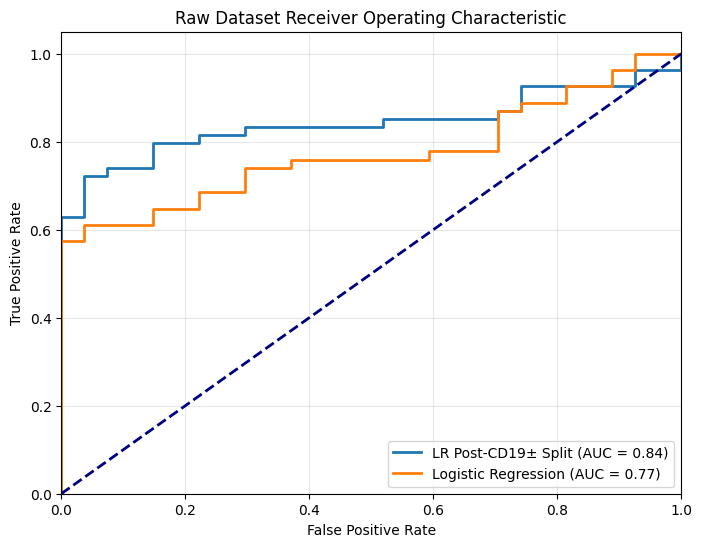

In [16]:
plt.figure(figsize=(8, 6))

lw = 2
fpr, tpr, roc_auc = models['lr_cd19']['roc_auc']
plt.plot(
    fpr, 
    tpr, 
    color=sns.color_palette("tab10")[0],
    lw=lw, 
    label=f"LR Post-CD19± Split (AUC = {roc_auc:.2f})"
)

# fpr, tpr, roc_auc = models['rf_cd19']['roc_auc']
# plt.plot(
#     fpr, 
#     tpr, 
#     color=sns.color_palette("tab10")[0],
#     lw=lw, 
#     label=f"RF Post-CD19± Split (AUC = {roc_auc:.2f})"
# )

fpr, tpr, roc_auc = models['lr_raw']['roc_auc']
plt.plot(
    fpr, 
    tpr, 
    color=sns.color_palette()[1],
    lw=lw, 
    label=f"Logistic Regression (AUC = {roc_auc:.2f})"
)

# fpr, tpr, roc_auc = models['rf_raw']['roc_auc']
# plt.plot(
#     fpr, 
#     tpr, 
#     color=sns.color_palette()[1],
#     lw=lw, 
#     label=f"Random Forest (AUC = {roc_auc:.2f})"
# )

plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Raw Dataset Receiver Operating Characteristic")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()